In [1]:
import torch
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam
from torchvision import transforms
from copy import deepcopy

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

import sqlite3
import pandas as pd

from info_nce import InfoNCE

from pathlib import Path
import sys

ROOT = Path.cwd().parents[1]
sys.path.append(str(ROOT))

from src.config.paths import EMBEDS_DIR, RESULTS, DB_PATH, MODEL_DIR
EMBED_PATH = EMBEDS_DIR/ "cont_embeds.pt"
EMBED_NAME = EMBED_PATH.stem

RESULTS_DIR = RESULTS / EMBED_NAME

In [2]:
contrastive_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [3]:
conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query("""
    SELECT path, split
    FROM meta
""", conn)

categories = pd.read_sql_query("SELECT DISTINCT category FROM meta", conn)["category"].to_list()

conn.close()

train_paths = df[df["split"] == "train"]["path"].to_list()
test_paths = df[df["split"] != "train"]["path"].to_list()

In [4]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

2.12.0+cu130
13.0
True
1


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {device}")

Device: cuda


In [6]:
dino = torch.hub.load(
            "facebookresearch/dinov2",
            "dinov2_vits14"
        )

dino.to(device)
dino.eval()

for p in dino.parameters():
    p.requires_grad = False

Using cache found in /home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [14]:
%load_ext autoreload
%autoreload 2

from src.fine_tune import ModelData, ProjectionHead, train_one_epoch, evaluate

from src.fine_tune.losses.combined_loss import CombinedLoss


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
LOSSES = {
    "category_cont" : True,
    "preservation": True
}

WEIGHTS = {
    "category_cont" : 1.0,
    "preservation": 0.3
}

In [16]:
BATCH_SIZE = 256
NUM_WORKERS = 8
PIN_MEMORY = device == "cuda"

MODEL_NAME = "info_nce_model.pt"

In [17]:
category_to_id = {category: idx for idx, category in enumerate(categories)}

dataset = ModelData(train_paths, root=ROOT, category_to_id=category_to_id, transform=contrastive_transform)
test_set = ModelData(test_paths, root=ROOT, category_to_id=category_to_id, transform=test_transform)

train_split = int(len(dataset) * 0.95)
val_split = len(dataset) - train_split

generator = torch.Generator().manual_seed(42)

train_set, val_set = random_split(
    dataset,
    [train_split, val_split],
    generator=generator
)

train_loader = DataLoader(
        train_set,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [18]:
epochs = 20

model = ProjectionHead(dim=384).to(device)

optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = CombinedLoss(enabled=LOSSES, weights=WEIGHTS)

In [ ]:

results = pd.DataFrame(columns=["epoch", "train_loss", "val_loss", "gap"])

best_val = float("inf")
best_state = None

try:
    for epoch in tqdm(range(epochs)):
        train_loss = train_one_epoch(model, dino, train_loader, criterion, optimizer, device)
        val_loss = evaluate(model, dino, val_loader, criterion, device)

        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())
            
        results.loc[len(results)] = {
            "epoch": epoch+1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "gap": abs(val_loss - train_loss)
        }
        
        print(results.tail(1).to_string(
            index=False,
            header=(epoch==0)
        ))

finally:
    if best_state is not None:
        torch.save(best_state, MODEL_DIR / MODEL_NAME)
        print(f"Best Model Saved (val_loss={best_val:.4f})")

  0%|          | 0/20 [00:00<?, ?it/s]

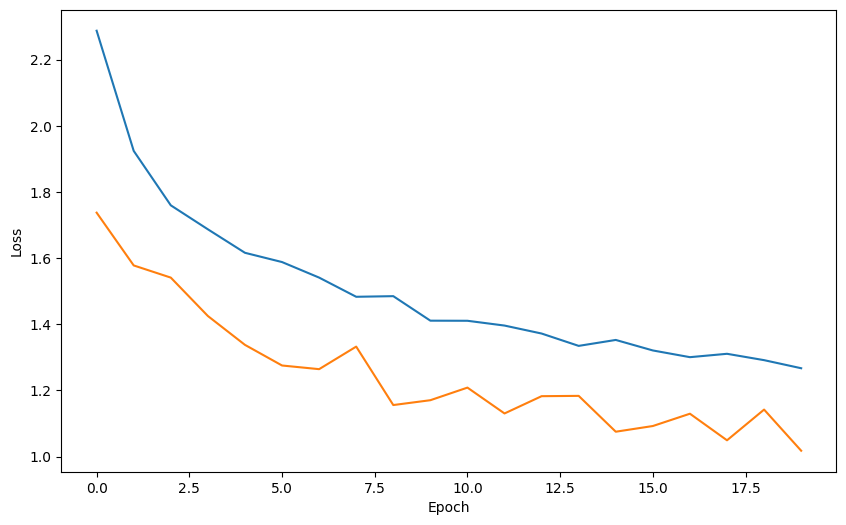

In [ ]:
fig = plt.figure(figsize=(10, 6))

plt.plot(range(epochs), results["train_loss"])
plt.plot(range(epochs), results["val_loss"])

plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.show()